验证volume constraint中,Sigma*相对于Sigma和F的gradient

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import rcParams
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [5]:
# 求解Sigma*的二维版本
def get_D(sigma_1, sigma_2):
    D, max_itr, tol = np.array([10., 10.]), 80, 1.e-6
    for itr in range(max_itr):
        aa, bb = D[0] + sigma_1, D[1] + sigma_2
        C = aa * bb - 1
        partial_C = np.array([bb, aa])
    
        D_temp = (partial_C.dot(D)-C) / np.linalg.norm(partial_C)**2 * partial_C
        D_error = np.linalg.norm(D-D_temp)
        D = D_temp
        if D_error < tol:
            break
    return np.array([D[0]+sigma_1, D[1]+sigma_2])

In [3]:
# F = np.array([[1.1, 0.2], [0.3, 0.9]])
F = np.array([[1.2, 0.], [0, 1.]])
U, s, Vh = np.linalg.svd(F)

ss = get_D(s[0], s[1])
PP = np.array([[ss[0], 0], [0, ss[1]]])
# print(PP)

In [4]:
s1 = np.linspace(0.1, 2, 100)
s2 = np.linspace(0.1, 2, 100)

ss1 = np.zeros((s1.shape[0], s2.shape[0]))
ss2 = np.zeros((s1.shape[0], s2.shape[0]))
x, y = np.meshgrid(s1, s2)

for i, j in np.ndindex(s1.shape[0], s2.shape[0]):
    ss1[i, j], ss2[i, j] = get_D(s1[i], s2[j])

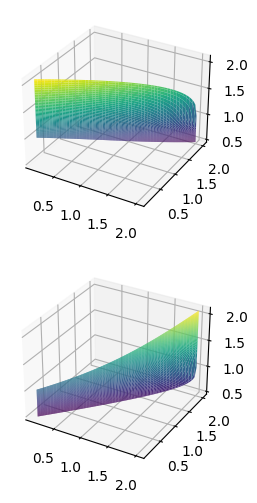

In [5]:
fig = plt.figure(figsize=(6,6), dpi=100)
gs = GridSpec(2, 1, figure=fig)

ax_ss1 = fig.add_subplot(gs[0], projection='3d')
ax_ss1.plot_surface(s1, s2, ss1, cmap='viridis')

ax_ss2 = fig.add_subplot(gs[1], projection='3d')
ax_ss2.plot_surface(s1, s2, ss2, cmap='viridis')

In [45]:
N = 1000
s1 = np.random.normal(1, 0.1, N)
s2 = np.random.normal(1, 0.1, N)

ss1, ss2 = np.zeros(N), np.zeros(N)
# dV = s1*s2 - 1
dV= 1 - s1*s2
dV_abs = np.abs(dV)

for i in range(N):
    ss1[i], ss2[i] = get_D(s1[i], s2[i])

# d是sigma*和sigma之间的距离, d_n是乘以√2, d_sigma是乘以sigma的模长
d = np.linalg.norm(np.array([s1, s2]) - np.array([ss1, ss2]), axis=0)
d_n = d * np.sqrt(2)
d_sigma = d * np.linalg.norm(np.array([ss1, ss2]), axis=0)
d_true = d * np.linalg.norm(np.array([ss1, ss2]), axis=0) - (ss1-s1)*(ss2-s2)*np.sign(dV)

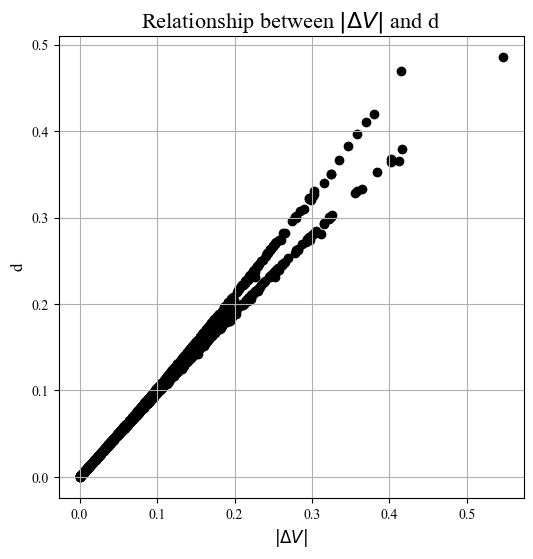

In [46]:
fig = plt.figure(figsize=(6,6), dpi=100)
gs = GridSpec(1, 1, figure=fig)

ax_dV = fig.add_subplot(gs[0])
ax_dV.scatter(dV_abs, d_n, c='k', marker='o')
ax_dV.set_title('Relationship between $|\Delta V|$ and d', fontsize=16)
ax_dV.set_xlabel('$|\Delta V|$', fontsize=12)
ax_dV.set_ylabel('d', fontsize=12)
ax_dV.grid('True')

In [47]:
model_d = LinearRegression(fit_intercept=False)

model_d.fit(dV_abs.reshape(-1, 1), d_n.reshape(-1, 1))
d_pred = model_d.predict(dV_abs.reshape(-1, 1))
slope_d = model_d.coef_[0][0]

mse = mean_squared_error(d_n, d_pred)
rmse = np.sqrt(mse)

print(f'回归系数 (slope): {slope_d}')
print(f"均方误差 (MSE): {mse}")
print(f"均方根误差 (RMSE): {rmse}")
print('------------------------------')

model_d_sigma = LinearRegression(fit_intercept=False)

model_d_sigma.fit(dV_abs.reshape(-1, 1), d_sigma.reshape(-1, 1))
d_pred_sigma = model_d_sigma.predict(dV_abs.reshape(-1, 1))
slope_sigma = model_d_sigma.coef_[0][0]

mse_sigma = mean_squared_error(d_sigma, d_pred_sigma)
rmse_sigma = np.sqrt(mse_sigma)

print(f'回归系数 (slope): {slope_sigma}')
print(f"均方误差 (MSE): {mse_sigma}")
print(f"均方根误差 (RMSE): {rmse_sigma}")

回归系数 (slope): 0.9945793539591151
均方误差 (MSE): 7.335525952228419e-05
均方根误差 (RMSE): 0.008564768503718252
------------------------------
回归系数 (slope): 0.9996772288093418
均方误差 (MSE): 7.150936126453783e-05
均方根误差 (RMSE): 0.008456320787702996


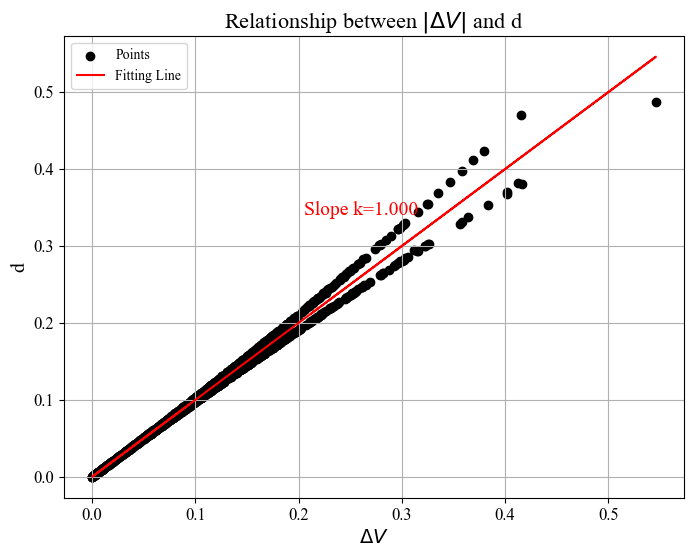

In [48]:
# 绘制散点图和回归线
fig = plt.figure(figsize=(8, 6), dpi=100)
gs = GridSpec(1, 1, figure=fig)

ax_fit = fig.add_subplot(gs[0])
ax_fit.scatter(dV_abs, d_sigma, color='black', label='Points')
ax_fit.plot(dV_abs, d_pred_sigma, color='red', label='Fitting Line')
x_annotate = 0.205
y_annotate = 0.34
ax_fit.text(x_annotate, y_annotate, f'Slope k={slope_sigma:.3f}', fontsize=14, color='red')
ax_fit.set_title('Relationship between $|\Delta V|$ and d', fontsize=16)
ax_fit.set_xlabel('$\Delta V$', fontsize=14)
ax_fit.set_ylabel('d', fontsize=14)
ax_fit.tick_params(axis='both', which='major', labelsize=12)
ax_fit.legend()
ax_fit.grid(True)

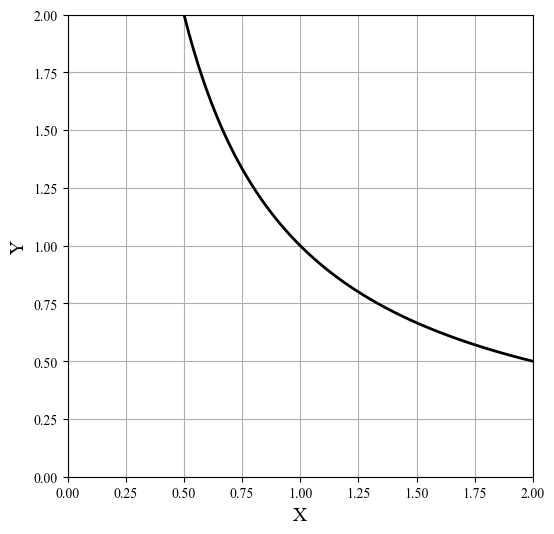

In [53]:
# plot f(x, y) = xy - 1 = 0的图像,用以文章中说明
x = np.linspace(0.1, 2, 100)
y = 1/x

fig = plt.figure(figsize=(6, 6), dpi=100)
gs = GridSpec(1, 1, figure=fig)

ax_fxy = fig.add_subplot(gs[0])
ax_fxy.plot(x, y, color='black', linewidth=2)
ax_fxy.set_xlim(0, 2)
ax_fxy.set_ylim(0, 2)
ax_fxy.set_xlabel('X', fontsize=14)
ax_fxy.set_ylabel('Y', fontsize=14)
ax_fit.tick_params(axis='both', which='major', labelsize=12)
ax_fxy.grid(True)

测试ss1/ss2=s1/s2来求解，与体积变化不成线性关系

In [20]:
def get_ss(s1, s2):
    ratio = s1/s2
    ss1 = np.sqrt(1/ratio)
    ss2 = np.sqrt(ratio)

    return ss1, ss2

In [26]:
N = 100
s1 = np.random.normal(1, 0.1, N)
s2 = np.random.normal(1, 0.1, N)

ss1, ss2 = np.zeros(N), np.zeros(N)
dV = s1*s2 - 1

for i in range(N):
    ss1[i], ss2[i] = get_ss(s1[i], s2[i])
    
d = np.linalg.norm(np.array([s1, s2]) - np.array([ss1, ss2]), axis=0)

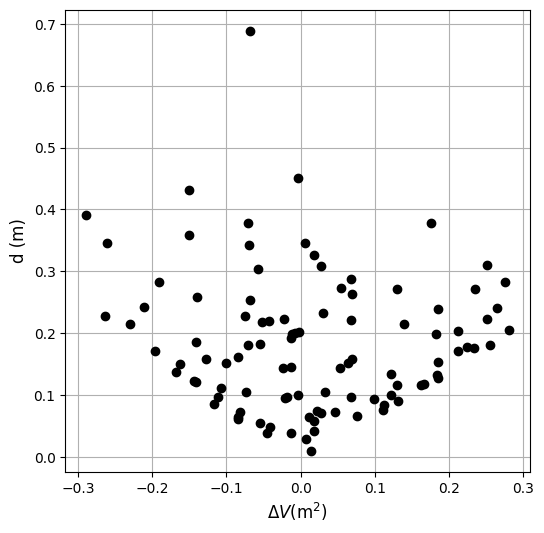

In [27]:
fig = plt.figure(figsize=(6,6), dpi=100)
gs = GridSpec(1, 1, figure=fig)

ax_dV = fig.add_subplot(gs[0])
ax_dV.plot(dV, d, c='k', marker='o', linestyle='None')
ax_dV.set_xlabel('$\Delta V (\mathrm{m^2})$', fontsize=12)
ax_dV.set_ylabel('d (m)', fontsize=12)
ax_dV.grid('True')

In [5]:
s1, s2 = 0.6, 0.7
ss1_init, ss2_init = get_D(s1, s2)
print(ss1_init, ss2_init)

delta = np.array([s1, s2]) - np.array([ss1_init, ss2_init])
delta_normalize = delta / np.linalg.norm(delta)
print(f'Direction: {delta_normalize}')

# 验证sigma在方向[sigma1-sigma1^*,sigma2-sigma2^*]变化是否会导致sigma^*变化
k_sequence = np.linspace(0, 0.5, 100)
ss1_list = []
ss2_list = []
for k in k_sequence:
    s1_tmp, s2_tmp = np.array([s1, s2]) + k * delta_normalize
    ss1_tmp, ss2_tmp = get_D(s1_tmp, s2_tmp)

    ss1_list.append(ss1_tmp)
    ss2_list.append(ss2_tmp)

0.9636604457676923 1.037709915761066
Direction: [-0.73276816 -0.68047838]


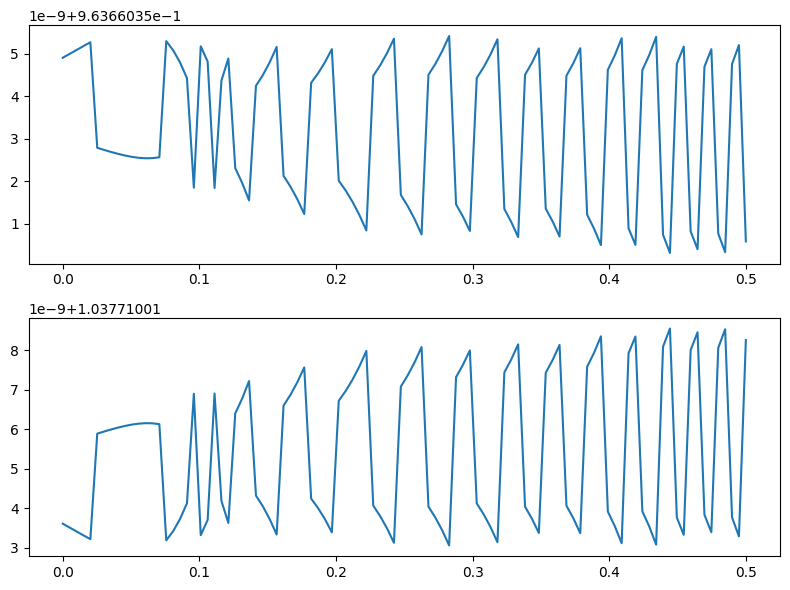

In [90]:
fig = plt.figure(figsize=(8,6), dpi=100)
gs = GridSpec(2, 1, figure=fig)

ax_ss1 = fig.add_subplot(gs[0])
ax_ss1.plot(k_sequence, ss1_list)

ax_ss2 = fig.add_subplot(gs[1])
ax_ss2.plot(k_sequence, ss2_list)

plt.tight_layout()
plt.show()

In [6]:
# 通过有限差分法计算Jacobian,并验证求解gradient的方程的准确性
finite_delta = 1.e-6
J = np.zeros((2, 2))            # 一阶矩阵
ss1_tmp, ss2_tmp = get_D(s1+finite_delta, s2)
J[:, 0] = (np.array([ss1_tmp, ss2_tmp]) - np.array([ss1_init, ss2_init])) / finite_delta

ss1_tmp, ss2_tmp = get_D(s1, s2+finite_delta)
J[:, 1] = (np.array([ss1_tmp, ss2_tmp]) - np.array([ss1_init, ss2_init])) / finite_delta

print(J)
print(np.dot(J[0,:],delta_normalize))

[[ 0.3431302  -0.36949774]
 [-0.36949683  0.39789079]]
3.455711603539413e-07


In [7]:
A = np.zeros((4, 4))
B = np.zeros((4, 1))

A[0, 0], A[0, 2] = ss2_init, ss1_init
A[1, 1], A[1, 3] = ss2_init, ss1_init

A[2, 0], A[2, 2] = (s1-2*ss1_init), -(s2-2*ss2_init)
A[3, 1], A[3, 3] = (s1-2*ss1_init), -(s2-2*ss2_init)

B[2] = -ss1_init
B[3] = ss2_init

print(A)
print(f'Finite Difference: {J.flatten()}')
print(f'Error: {A@J.flatten()-B.flatten()}')

sol = np.linalg.solve(A, B)
print(f'Solution: {sol.flatten()}')

[[ 1.03770992  0.          0.96366045  0.        ]
 [ 0.          1.03770992  0.          0.96366045]
 [-1.32732089  0.          1.37541983  0.        ]
 [ 0.         -1.32732089  0.          1.37541983]]
Finite Difference: [ 0.3431302  -0.36949774 -0.36949683  0.39789079]
Error: [ 1.26860522e-07  1.47046795e-07  3.29750503e-06 -9.52764857e-07]
Solution: [ 0.34313131 -0.36949816 -0.36949816  0.39789109]


下面是3D的情况

In [8]:
# 求解Sigma*的三维版本
def get_D_3d(sigma_1, sigma_2, sigma_3):
    D, max_itr, tol = np.array([10., 10., 10.]), 80, 1.e-9
    for itr in range(max_itr):
        aa, bb, cc = D[0] + sigma_1, D[1] + sigma_2, D[2] + sigma_3
        C = aa * bb * cc - 1
        partial_C = np.array([bb*cc, aa*cc, aa*bb])
    
        D_temp = (partial_C.dot(D)-C) / partial_C.dot(partial_C) * partial_C
        D_error = np.linalg.norm(D-D_temp)
        D = D_temp
        if D_error < tol:
            break
    return np.array([D[0]+sigma_1, D[1]+sigma_2, D[2]+sigma_3])

In [9]:
# s1, s2, s3 = 0.6, 0.7, 0.8
s1, s2, s3 = 0.8, 1., 1.25
ss1_init, ss2_init, ss3_init = get_D_3d(s1, s2, s3)
print(ss1_init, ss2_init, ss3_init)

finite_delta = 1.e-6
J = np.zeros((3, 3))            # 一阶矩阵
ss1_tmp, ss2_tmp, ss3_tmp = get_D_3d(s1+finite_delta, s2, s3)
J[:, 0] = (np.array([ss1_tmp, ss2_tmp, ss3_tmp]) - np.array([ss1_init, ss2_init, ss3_init])) / finite_delta

ss1_tmp, ss2_tmp, ss3_tmp = get_D_3d(s1, s2+finite_delta, s3)
J[:, 1] = (np.array([ss1_tmp, ss2_tmp, ss3_tmp]) - np.array([ss1_init, ss2_init, ss3_init])) / finite_delta

ss1_tmp, ss2_tmp, ss3_tmp = get_D_3d(s1, s2, s3+finite_delta)
J[:, 2] = (np.array([ss1_tmp, ss2_tmp, ss3_tmp]) - np.array([ss1_init, ss2_init, ss3_init])) / finite_delta

print(J)
# print(np.dot(J[0,:],delta_normalize))

0.8 1.0 1.25
[[ 0.51210029 -0.39032008 -0.31225601]
 [-0.39032017  0.6877443  -0.24980477]
 [-0.31225609 -0.24980478  0.80015636]]


In [18]:
A = np.zeros((9, 9))
B = np.zeros((9, 1))

A[0, 0], A[0, 3], A[0, 6] = ss2_init*ss3_init, ss1_init*ss3_init, ss1_init*ss2_init
A[1, 1], A[1, 4], A[1, 7] = ss2_init*ss3_init, ss1_init*ss3_init, ss1_init*ss2_init
A[2, 2], A[2, 5], A[2, 8] = ss2_init*ss3_init, ss1_init*ss3_init, ss1_init*ss2_init

A[3, 0], A[3, 6] = (s1-2*ss1_init), -(s3-2*ss3_init)
A[4, 1], A[4, 7] = (s1-2*ss1_init), -(s3-2*ss3_init)
A[5, 2], A[5, 8] = (s1-2*ss1_init), -(s3-2*ss3_init)

A[6, 3], A[6, 6] = (s2-2*ss2_init), -(s3-2*ss3_init)
A[7, 4], A[7, 7] = (s2-2*ss2_init), -(s3-2*ss3_init)
A[8, 5], A[8, 8] = (s2-2*ss2_init), -(s3-2*ss3_init)

B[3] = -ss1_init
B[5] = ss3_init
B[7] = -ss2_init
B[8] = ss3_init

print(A)
print(B.transpose())
print(f'Finite Difference solution: {J.flatten()}')
print(f'Error: {A@J.flatten()-B.flatten()}')

# sol = np.linalg.solve(A, B)
sol = np.linalg.inv(A) @ B
print(f'Solution: {sol.flatten()}')
print(f'Solution Error: {sol.flatten()-J.flatten()}')

[[ 1.25  0.    0.    1.    0.    0.    0.8   0.    0.  ]
 [ 0.    1.25  0.    0.    1.    0.    0.    0.8   0.  ]
 [ 0.    0.    1.25  0.    0.    1.    0.    0.    0.8 ]
 [-0.8   0.    0.    0.    0.    0.    1.25  0.    0.  ]
 [ 0.   -0.8   0.    0.    0.    0.    0.    1.25  0.  ]
 [ 0.    0.   -0.8   0.    0.    0.    0.    0.    1.25]
 [ 0.    0.    0.   -1.    0.    0.    1.25  0.    0.  ]
 [ 0.    0.    0.    0.   -1.    0.    0.    1.25  0.  ]
 [ 0.    0.    0.    0.    0.   -1.    0.    0.    1.25]]
[[ 0.    0.    0.   -0.8   0.    1.25  0.   -1.    1.25]]
Finite Difference solution: [ 0.51210029 -0.39032008 -0.31225601 -0.39032017  0.6877443  -0.24980477
 -0.31225609 -0.24980478  0.80015636]
Error: [ 3.12244675e-07  3.75272036e-07  3.12322390e-07 -3.47433993e-07
  8.98392472e-08  2.57413397e-07  5.48450174e-08 -2.77251445e-07
  2.22330350e-07]
Solution: [ 0.51209992 -0.39032006 -0.31225605 -0.39032006  0.68774395 -0.24980484
 -0.31225605 -0.24980484  0.80015613]
Solution Erro

In [117]:
def lu_decomposition(A):
    n = len(A)
    L = np.zeros((n, n))
    U = np.zeros((n, n))
    
    for i in range(n):
        L[i, i] = 1
        for j in range(i, n):
            U[i, j] = A[i, j] - sum(L[i, k] * U[k, j] for k in range(i))
        for j in range(i + 1, n):
            L[j, i] = (A[j, i] - sum(L[j, k] * U[k, i] for k in range(i))) / U[i, i]
    
    return L, U

def forward_substitution(L, b):
    n = len(b)
    y = np.zeros(n)
    for i in range(n):
        y[i] = (b[i] - sum(L[i, j] * y[j] for j in range(i))) / L[i, i]
    return y

def backward_substitution(U, y):
    n = len(y)
    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = (y[i] - sum(U[i, j] * x[j] for j in range(i + 1, n))) / U[i, i]
    return x

# b = np.random.rand(9)
L, U = lu_decomposition(A)
y = forward_substitution(L, B)
x = backward_substitution(U, y)

print("Solution using LU decomposition:", x)


Solution using LU decomposition: [ 0.51209992 -0.39032006 -0.31225605 -0.39032006  0.68774395 -0.24980484
 -0.31225605 -0.24980484  0.80015613]


In [16]:
def qr_decomposition(A):
    n = A.shape[0]
    Q = np.zeros_like(A)
    R = np.zeros((n, n))

    for k in range(n):
        Q[:, k] = A[:, k]
        for i in range(k):
            R[i, k] = np.dot(Q[:, i], A[:, k])
            Q[:, k] -= R[i, k] * Q[:, i]
        R[k, k] = np.linalg.norm(Q[:, k])
        Q[:, k] /= R[k, k]

    return Q, R

def solve_qr(Q, R, b):
    y = np.dot(Q.T, b)
    x = np.zeros_like(b)
    n = len(b)
    Rx = np.zeros_like(b)
    # for i in range(n-1, -1, -1):
    #     x[i] = (y[i] - np.dot(R[i, i:], x[i:])) / R[i, i]
    for i in range(n):
        j = n - 1 - i
        for k in range(j, n):
            Rx[j] += R[j, k] * x[k]
        x[j] = (y[j] - Rx[j]) / R[j, j]
    return x

Q, R = qr_decomposition(A)
x = solve_qr(Q, R, B)

print("Solution using QR decomposition:", x.transpose())

Solution using QR decomposition: [[ 0.51209992 -0.39032006 -0.31225605 -0.39032006  0.68774395 -0.24980484
  -0.31225605 -0.24980484  0.80015613]]
